In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
data = pd.read_csv(r"\Users\annec\Python_DeCal_Fa2025\course_assignments\homework9\noisy_curvefit_data.csv")
df = pd.DataFrame(data)

In [4]:
df.shape # 100, 6
# 100 rows, 6 columns

(100, 6)

In [5]:
df.head()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


In [6]:
df.tail() # x, y_noise_1, y_noise_2, y_noise_3, y_noise_4, y_noise_5

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850


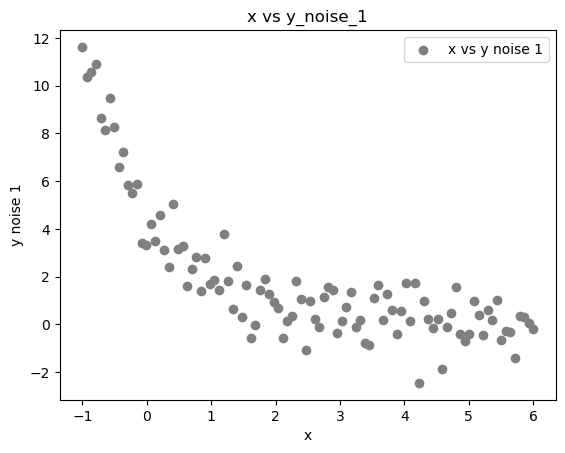

In [7]:
plt.figure()
plt.scatter(df["x"], df["y_noise_1"], color = "grey", label = "x vs y noise 1")
plt.xlabel("x")
plt.ylabel("y noise 1")
plt.title("x vs y_noise_1")
plt.legend()
plt.show()

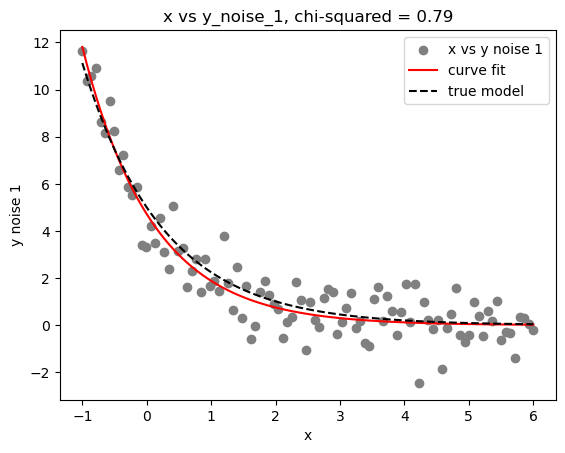

In [8]:
def model(x, A, k):
    return A * np.exp(-k * x)

x = df["x"].values
y_noise_1 = df["y_noise_1"].values
    
p0 = [1, 1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
A_fit, k_fit = popt
f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)"
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

plt.figure()
plt.scatter(df["x"], df["y_noise_1"], color = "grey", label = "x vs y noise 1")
plt.plot(x, model(x, A_fit, k_fit), label = "curve fit", color = "red")
plt.plot(x, model(x, 5, 0.8), label = "true model", color = "black", linestyle = "--")
plt.xlabel("x")
plt.ylabel("y noise 1")
plt.title(f"x vs y_noise_1, chi-squared = {chi2_reduced:.2f}")
plt.legend()
plt.show()

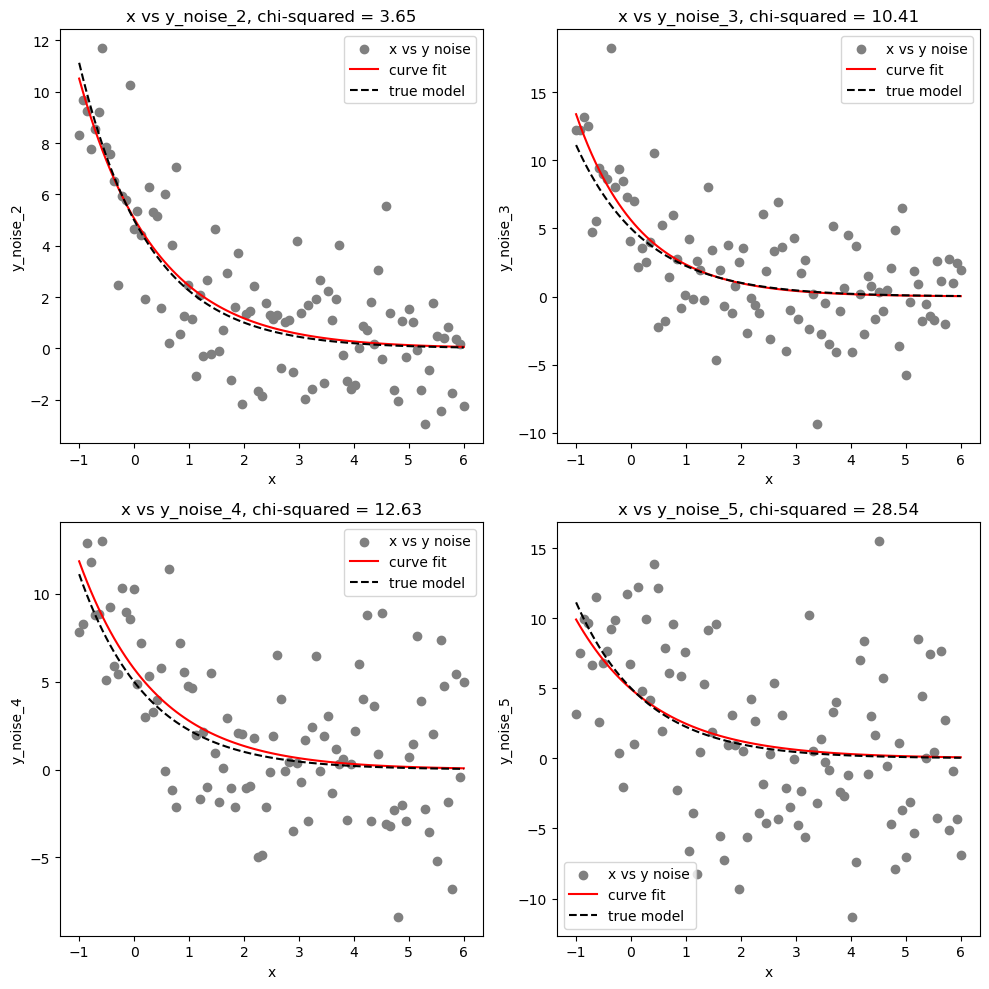

In [9]:
def fit_model(x, y):
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)"
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    return popt, chi2_reduced

A_fit = []
k_fit = []
chi_squared = []

fig, ax = plt.subplots(2,2, figsize = (10, 10))
y_noise = ["y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]
x_positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
zipped_function = zip(y_noise, x_positions)
for i, (y, (a, b)) in enumerate(zipped_function):
    popt, chi2_reduced = fit_model(df["x"], df[y])
    A_fit2, k_fit2 = popt
    A_fit.append(A_fit2)
    k_fit.append(k_fit2)
    chi_squared.append(chi2_reduced)
    
    ax[a,b].scatter(df["x"], df[y], color = "grey", label = "x vs y noise")
    ax[a,b].plot(x, model(x, A_fit2, k_fit2), label = "curve fit", color = "red")
    ax[a,b].plot(x, model(x, 5, 0.8), label = "true model", color = "black", linestyle = "--")
    ax[a,b].set_xlabel("x")
    ax[a,b].set_ylabel(f"{y}")
    ax[a,b].set_title(f"x vs {y}, chi-squared = {chi2_reduced:.2f}")
    ax[a,b].legend()

plt.tight_layout()
plt.show()

In [10]:
# as the noise level increases, the red and black dotted lines get less curved, this is because the noise is more scattered
# the reduced chi-squared increases, this is because there's a poorer fit between the curve and the data

In [51]:
# print(fit_model(x, y_noise_1)) # y noise1 a fit, k fit, and reduced chi squared
y_noise_1_dict = {
    "Noise Level": ["y_noise_1"],
    "A fit": [4.71481388],
    "k fit": [0.91830785],
    "Reduced chi-squared": [0.7906732087457313]
}
y_noise_df = pd.DataFrame(y_noise_1_dict)

data = {
    "Noise Level": y_noise,
    "A fit": A_fit,
    "k fit": k_fit,
    "Reduced chi-squared": chi_squared
}

new_df = pd.DataFrame(data)
new_new_df = y_noise_df._append(new_df, ignore_index = True)
new_new_df

new_new_df.to_csv("noisy_parameters.csv", index=False)